# STEP 3 텍스트 전처리 파이프라인

## 분석 개요
Yelp 리뷰 데이터를 활용하여 **프랜차이즈 경쟁압력(FPI)** 이 독립 브랜드 평점 및 소비자 언어에 미치는 영향을 분석


| 단계 | 내용 |
|------|------|
| STEP 3-1 | 텍스트 클리닝 (소문자화, 불용어 제거, 어간 추출) |
| STEP 3-2 | DTM 생성 (파라미터 민감도 분석 포함) |
| STEP 3-3 | TF-IDF 변환 |
| STEP 3-4 | 시각화 (파라미터 비교, 워드클라우드, 히트맵) |

---
**입력 데이터**
- `biz_target.csv` : Las Vegas NV Restaurants 업체 5,899개
- `review_target.csv` : 리뷰 929,606개

## 공통 라이브러리 및 설정

분석에 필요한 라이브러리를 불러오고 경로, 파라미터를 설정

- `MIN_DF_RATE = 0.1` : 전체 브랜드의 10% 미만에서만 등장하는 희소 단어 제거
- `MAX_DF_RATE = 0.9` : 전체 브랜드의 90% 이상에서 등장하는 공통 단어 제거
- `REVIEW_PROP_CONDITIONS = [0.3, 0.1]` : 브랜드 내 리뷰 비율 기준 비교 (0.3을 최종 채택)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from tqdm import tqdm
tqdm.pandas()

PATH_to_data = r'C:\Users\seonu\Documents\yelp-franchise-analysis\results'
PATH_to_save = r'C:\Users\seonu\Documents\yelp-franchise-analysis\results'

BIZ_CAT = "Restaurants"
STATE   = "NV"

MIN_DF_RATE     = 0.1
MAX_DF_RATE     = 0.9
MIN_DOC_COUNT   = 10

REVIEW_PROP_CONDITIONS = [0.3, 0.1]

MANUAL_STOPWORDS = [
    'al', "also", "alway", 'anoth', 'area', 'around', 'ask',
    'back', 'bite', 'box',
    'come', 'could', 'came',
    'dont', 'day', 'de', 'didnt',
    'even', 'ever', 'el',
    'get', 'give', 'got',
    'im', 'ive',
    'let', 'la', 'last',
    'make', 'made', 'mayb',
    'name',
    'one',
    'round',
    'someth', 'still', 'seem', 'sinc', 'sub', 'said',
    'told', 'that', 'think', 'two', 'though', 'thought', 'took',
    'us',
    'want', 'way', 'went', 'would', 'wasnt',
    'your', 'year',
]

META_COLS_POOL = [
    'user_id', 'name', 'review_count', 'avg_stars',
    'useful_count', 'funny_count', 'cool_count', 'categories'
]

---
## STEP 3-1 텍스트 클리닝

### 결과
- 브랜드 수: **4,228개**
- 저장 파일: `reviews_restaurants_nv_perBrand.csv`

In [2]:
def step3_1_cleaning():
    print("\n" + "="*60)
    print("STEP 3-1  텍스트 클리닝")
    print("="*60)

    print("  [3-1-0] biz_target.csv / review_target.csv 로드 중...")
    biz    = pd.read_csv(f"{PATH_to_data}/biz_target.csv")
    review = pd.read_csv(f"{PATH_to_data}/review_target.csv")
    print(f"          -> 업체 수: {len(biz):,}개 / 리뷰 수: {len(review):,}개")

    print("  [3-1-1] 브랜드별 리뷰 aggregation 중...")
    name_col = 'name_clean' if 'name_clean' in biz.columns else 'name'

    reviews_slted = pd.merge(
        review,
        biz[['business_id', name_col, 'categories']],
        on='business_id', how='inner'
    )
    brand_reviews = (reviews_slted
                     .groupby(name_col)
                     .agg(review_id=('review_id', 'count'),
                          stars=('stars', 'mean'),
                          text=('text', ' '.join),
                          useful=('useful', 'sum'),
                          funny=('funny', 'sum'),
                          cool=('cool', 'sum'))
                     .reset_index()
                     .rename(columns={name_col: 'name',
                                      'review_id': 'review_count',
                                      'stars': 'avg_stars',
                                      'text': 'pooled_text',
                                      'useful': 'useful_count',
                                      'funny': 'funny_count',
                                      'cool': 'cool_count'}))
    brand_reviews = pd.merge(
        brand_reviews,
        reviews_slted[[name_col, 'categories']].drop_duplicates(subset=[name_col], keep='first').rename(columns={name_col: 'name'}),
        on='name', how='left'
    )
    brand_reviews = (brand_reviews
                     .sort_values(by='review_count', ascending=False)
                     .reset_index(drop=True)
                     .reset_index()
                     .rename(columns={'index': 'doc_id'}))
    print(f"          -> 브랜드 수: {len(brand_reviews):,}개")

    print("  [3-1-2] 소문자화 / 숫자·구두점 제거 / 어간추출 중... (시간 소요)")
    import gc
    import re
    nltk.download('stopwords', quiet=True)
    stop_words = set(stopwords.words('english')) | {"does", "not", "thing"}
    stemmer    = PorterStemmer()

    def tokenize_filter_stem(text):
        tokens = text.split()
        tokens = [w for w in tokens if w not in stop_words]
        tokens = [stemmer.stem(w) for w in tokens]
        return ' '.join(tokens)

    def clean_text(text):
        text = text.lower()
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'[^\w\s]', '', text)
        return tokenize_filter_stem(text)

    chunk_size = 10
    cleaned_chunks = []
    for i in tqdm(range(0, len(brand_reviews), chunk_size), desc="텍스트 전처리"):
        chunk = brand_reviews['pooled_text'].iloc[i:i+chunk_size].apply(clean_text)
        cleaned_chunks.append(chunk)
        gc.collect()

    brand_reviews['pooled_text_clean'] = pd.concat(cleaned_chunks).reset_index(drop=True)
    brand_reviews = brand_reviews.drop(columns=['pooled_text'])

    out_name = "reviews_restaurants_nv_perBrand"
    brand_reviews.to_csv(f"{PATH_to_save}/{out_name}.csv", index=False, encoding='utf-8-sig')
    print(f"  -> 저장 완료: {out_name}.csv  ({len(brand_reviews):,}개 브랜드)")
    return brand_reviews, out_name

---
## STEP 3-2 DTM 생성

### 단어 필터링 4단계
| 단계 | 기준 | 목적 |
|------|------|------|
| 1 | CountVectorizer 초기 생성 | 전체 단어 추출 |
| 2 | `df_rate` 0.1 ~ 0.9 | 너무 희소하거나 너무 흔한 단어 제거 |
| 3 | `min_review_prop` 기준 | 브랜드 내 리뷰 비율 미달 단어 제거 |
| 4 | `min_doc_count = 10` | 10개 미만 브랜드에만 등장하는 단어 제거 |

### 파라미터 비교 결과
- `min_review_prop = 0.3` → 최종 단어 수 **902개** ✅ 채택 (노이즈 감소 효과 우수)
- `min_review_prop = 0.1` → 최종 단어 수 **2,288개**

![image.png](attachment:image.png)

In [3]:
def step3_2_dtm(brand_reviews, input_file_name,
                min_df_rate, max_df_rate,
                min_review_prop_in_doc, min_doc_count_finally,
                manual_stopwords):
    print("\n" + "="*60)
    print(f"STEP 3-2  DTM 생성  (min_review_prop={min_review_prop_in_doc})")
    print("="*60)

    print("  [3-2-1] CountVectorizer로 초기 DTM 생성 중...")
    nltk_stop  = stopwords.words('english')
    stop_words = sorted(list(set(nltk_stop)))

    vectorizer = CountVectorizer(stop_words=stop_words)
    dtm        = vectorizer.fit_transform(brand_reviews['pooled_text_clean'])
    terms      = vectorizer.get_feature_names_out()
    print(f"          -> 초기 단어 수: {len(terms):,}개")

    print("  [3-2-2] df_rate 기준 희소·공통 단어 제거 중...")
    term_frequencies = np.asarray((dtm > 0).sum(axis=0)).flatten()
    doc_count        = dtm.shape[0]
    df_rate          = term_frequencies / doc_count

    word_mask     = (df_rate >= min_df_rate) & (df_rate < max_df_rate)
    dtm_reduced   = dtm[:, word_mask]
    terms_reduced = terms[word_mask]

    sparse_words = terms[df_rate < min_df_rate]
    common_words = terms[df_rate >= max_df_rate]
    print(f"          -> 희소단어 제거: {len(sparse_words):,}개 / 공통단어 제거: {len(common_words):,}개")
    print(f"          -> 남은 단어 수: {len(terms_reduced):,}개")

    dtm_df = pd.DataFrame(dtm_reduced.toarray(), columns=terms_reduced)
    dtm_df['doc_id'] = brand_reviews['doc_id'].values

    print("  [3-2-3] 문서별 min_review_prop 기준 단어 필터링 중...")
    dtm_df = dtm_df.set_index('doc_id').astype(float)
    review_count   = brand_reviews.set_index('doc_id')['review_count']
    dtm_normalized = dtm_df.div(review_count, axis=0)

    high_freq_terms_per_doc = []
    for _, row in dtm_normalized.iterrows():
        high_terms = row[row >= min_review_prop_in_doc].index.tolist()
        high_freq_terms_per_doc.append(high_terms)

    high_freq_terms = sorted(list(set(
        item for batch in high_freq_terms_per_doc for item in batch
    )))
    print(f"          -> review_prop 필터 후 단어 수: {len(high_freq_terms):,}개")

    print("  [3-2-4] 최소 문서수 기준 추가 필터링 중...")
    term_doc_counts = {
        term: sum(term in tl for tl in high_freq_terms_per_doc)
        for term in high_freq_terms
    }
    term_doc_df    = pd.DataFrame(list(term_doc_counts.items()), columns=['term', 'doc_count'])
    words_features = term_doc_df[term_doc_df['doc_count'] > min_doc_count_finally]['term'].tolist()
    dtm_df         = dtm_df[words_features]
    print(f"          -> 최종 단어 수: {len(words_features):,}개")

    print("  [3-2-5] 수동 불용어 제거 중...")
    dtm_df_cleaned = dtm_df.copy()
    to_drop        = [w for w in manual_stopwords if w in dtm_df_cleaned.columns]
    dtm_df_cleaned = dtm_df_cleaned.drop(to_drop, axis=1)
    dtm_df_cleaned = dtm_df_cleaned.loc[~(dtm_df_cleaned == 0).all(axis=1)]
    dtm_df_cleaned = dtm_df_cleaned.loc[:, ~(dtm_df_cleaned == 0).all(axis=0)]

    brand_reviews_dtm = pd.merge(
        brand_reviews.drop(columns=['pooled_text_clean']),
        dtm_df_cleaned.reset_index(),
        on='doc_id', how='inner'
    ).set_index('doc_id')

    dtm_file_name = (f"{input_file_name}_{min_df_rate}_{max_df_rate}"
                     f"_{min_review_prop_in_doc}_{min_doc_count_finally}_dtm")
    brand_reviews_dtm.to_csv(f"{PATH_to_save}/{dtm_file_name}.csv", index=False, encoding='utf-8-sig')
    print(f"  -> 저장 완료: {dtm_file_name}.csv")

    word_count_log = {
        'initial':    len(terms),
        'after_df':   len(terms_reduced),
        'after_prop': len(high_freq_terms),
        'final':      dtm_df_cleaned.shape[1],
    }
    return brand_reviews_dtm, dtm_file_name, word_count_log

---
## STEP 3-3 TF-IDF 변환

### 두 가지 버전 생성
| 파일 | norm | 용도 |
|------|------|------|
| `_tfidf.csv` | 없음 | 원본 TF-IDF 값 (STEP 4 감성분석에 활용) |
| `_tfidf_l2.csv` | L2 정규화 | 브랜드 간 비교 시 문서 길이 영향 제거 |

In [4]:
def step3_3_tfidf(brand_reviews_dtm, dtm_file_name, apply_l2):
    print("\n" + "="*60)
    print(f"STEP 3-3  TF-IDF 변환  (L2 norm: {apply_l2})")
    print("="*60)

    df = brand_reviews_dtm.reset_index() if 'doc_id' in brand_reviews_dtm.index.names else brand_reviews_dtm.copy()

    meta_cols = [col for col in df.columns if col in META_COLS_POOL]
    dtm_cols  = [col for col in df.columns if col not in meta_cols]

    df_meta = df[meta_cols]
    df_dtm  = df[dtm_cols]

    norm   = 'l2' if apply_l2 else None
    tfidf  = TfidfTransformer(norm=norm)
    result = tfidf.fit_transform(df_dtm)

    df_tfidf = pd.DataFrame(result.toarray(), columns=dtm_cols).round(5)
    df_tfidf = pd.concat([df_meta.reset_index(drop=True), df_tfidf], axis=1)

    suffix   = "_tfidf_l2" if apply_l2 else "_tfidf"
    out_name = f"{dtm_file_name}{suffix}"
    df_tfidf.to_csv(f"{PATH_to_save}/{out_name}.csv", encoding='utf-8-sig', index=False)
    print(f"  -> 저장 완료: {out_name}.csv")
    return df_tfidf

---
## STEP 3-4 시각화

### 3-4-1 파라미터 비교 바차트
`min_review_prop = 0.3` vs `0.1` 조건에서 단계별 단어 수 변화를 비교합니다.

**결과 해석**: `min_review_prop = 0.3` 조건이 최종 902개 단어로 노이즈를 더 효과적으로 제거하여 채택하였습니다.

In [5]:
def step3_4_1_param_comparison(word_count_logs: dict):
    print("\n" + "="*60)
    print("STEP 3-4-1  파라미터 비교 바차트")
    print("="*60)

    stages = ['초기\n단어수', 'df_rate\n필터 후', 'review_prop\n필터 후', '최종\n단어수']
    colors = ['#4C72B0', '#DD8452']
    props  = list(word_count_logs.keys())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('STEP 3-2  DTM 파라미터 민감도 분석\n(min_review_prop 조건별 단어 수 변화)',
                 fontsize=14, fontweight='bold', y=1.02)

    for ax, prop, color in zip(axes, props, colors):
        log    = word_count_logs[prop]
        values = [log['initial'], log['after_df'], log['after_prop'], log['final']]
        bars   = ax.bar(stages, values, color=color, alpha=0.85, edgecolor='white', width=0.5)
        ax.set_title(f'min_review_prop = {prop}', fontsize=12, fontweight='bold')
        ax.set_ylabel('단어 수')
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                    f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax.set_ylim(0, max(values) * 1.15)
        ax.spines[['top', 'right']].set_visible(False)

    finals = {p: word_count_logs[p]['final'] for p in props}
    fig.text(0.5, -0.04,
             f"※ 채택: min_review_prop = {props[0]}  "
             f"(최종 단어수 {finals[props[0]]:,}개, 노이즈 감소 효과 우수)",
             ha='center', fontsize=11, color='#333333',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3CD', edgecolor='#FFC107'))

    plt.tight_layout()
    plt.savefig(f"{PATH_to_save}/viz_3_4_1_param_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("  -> 저장 완료: viz_3_4_1_param_comparison.png")

### 3-4-2 TF-IDF 워드클라우드

전체 브랜드의 평균 TF-IDF 점수를 기반으로 상위 100개 키워드를 시각화합니다.

**결과 해석**: `best`, `restaurant`, `chicken`, `sushi`, `vega` 등 Las Vegas 레스토랑 특성을 잘 반영하는 키워드가 상위에 위치합니다.

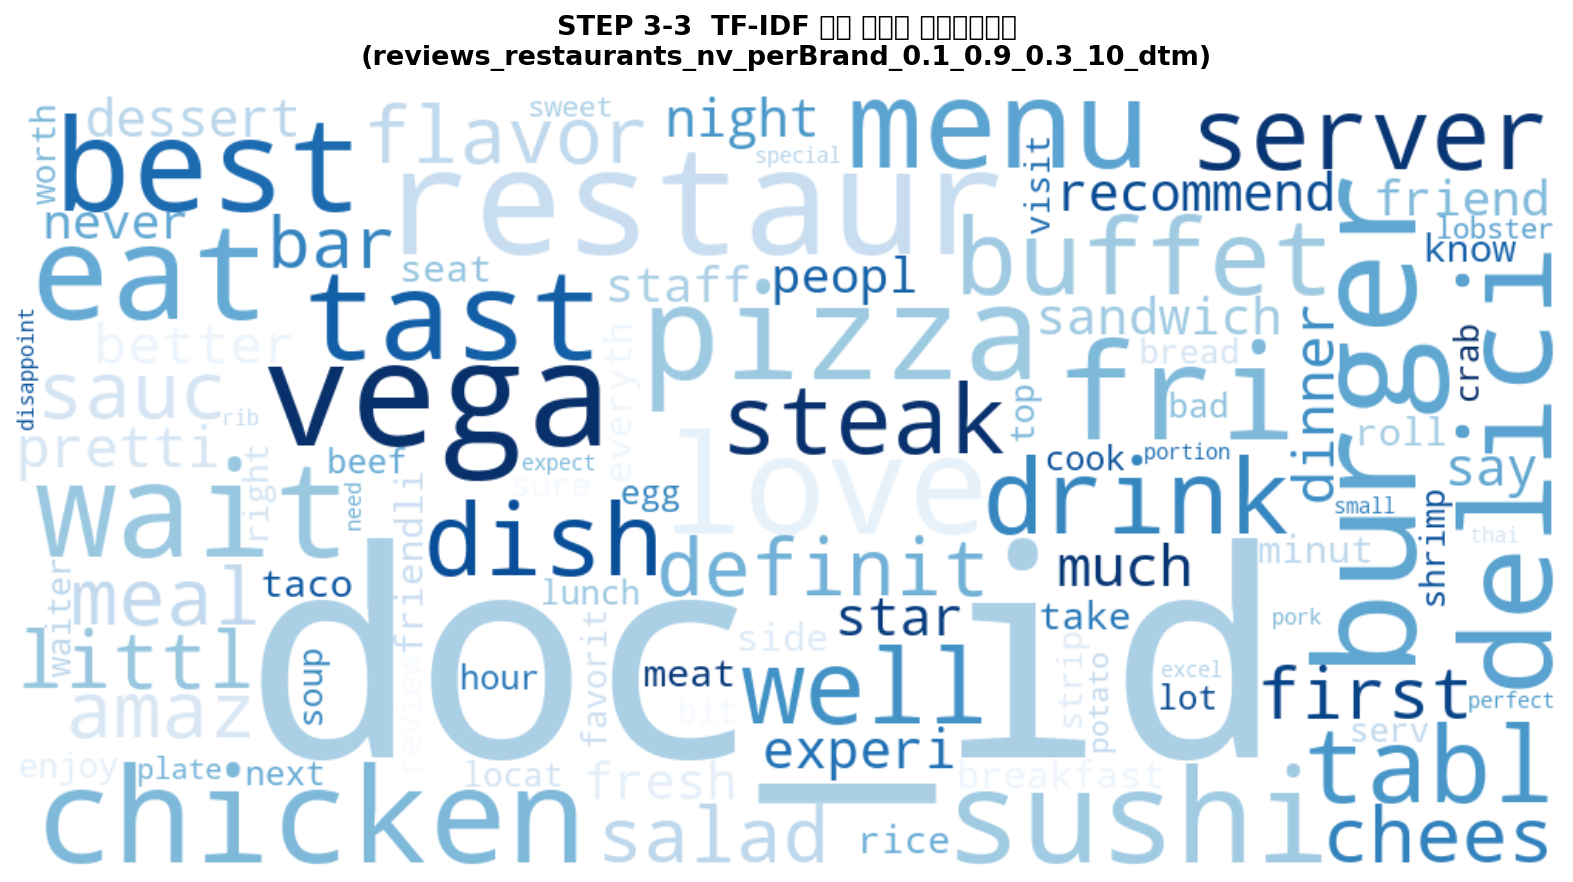

In [6]:
def step3_4_2_wordcloud(df_tfidf, dtm_file_name):
    print("\n" + "="*60)
    print("STEP 3-4-2  TF-IDF 워드클라우드")
    print("="*60)

    meta_cols  = [col for col in df_tfidf.columns if col in META_COLS_POOL]
    tfidf_cols = [col for col in df_tfidf.columns if col not in meta_cols]
    word_scores = df_tfidf[tfidf_cols].mean(axis=0).to_dict()

    wc = WordCloud(
        width=1000, height=500,
        background_color='white',
        colormap='Blues',
        max_words=100,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(word_scores)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'STEP 3-3  TF-IDF 상위 키워드 워드클라우드\n({dtm_file_name})',
                 fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(f"{PATH_to_save}/viz_3_4_2_wordcloud.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("  -> 저장 완료: viz_3_4_2_wordcloud.png")

### 3-4-3 브랜드 × 단어 TF-IDF 히트맵

리뷰 수 상위 15개 브랜드와 상위 30개 단어의 TF-IDF 점수를 히트맵으로 시각화합니다.

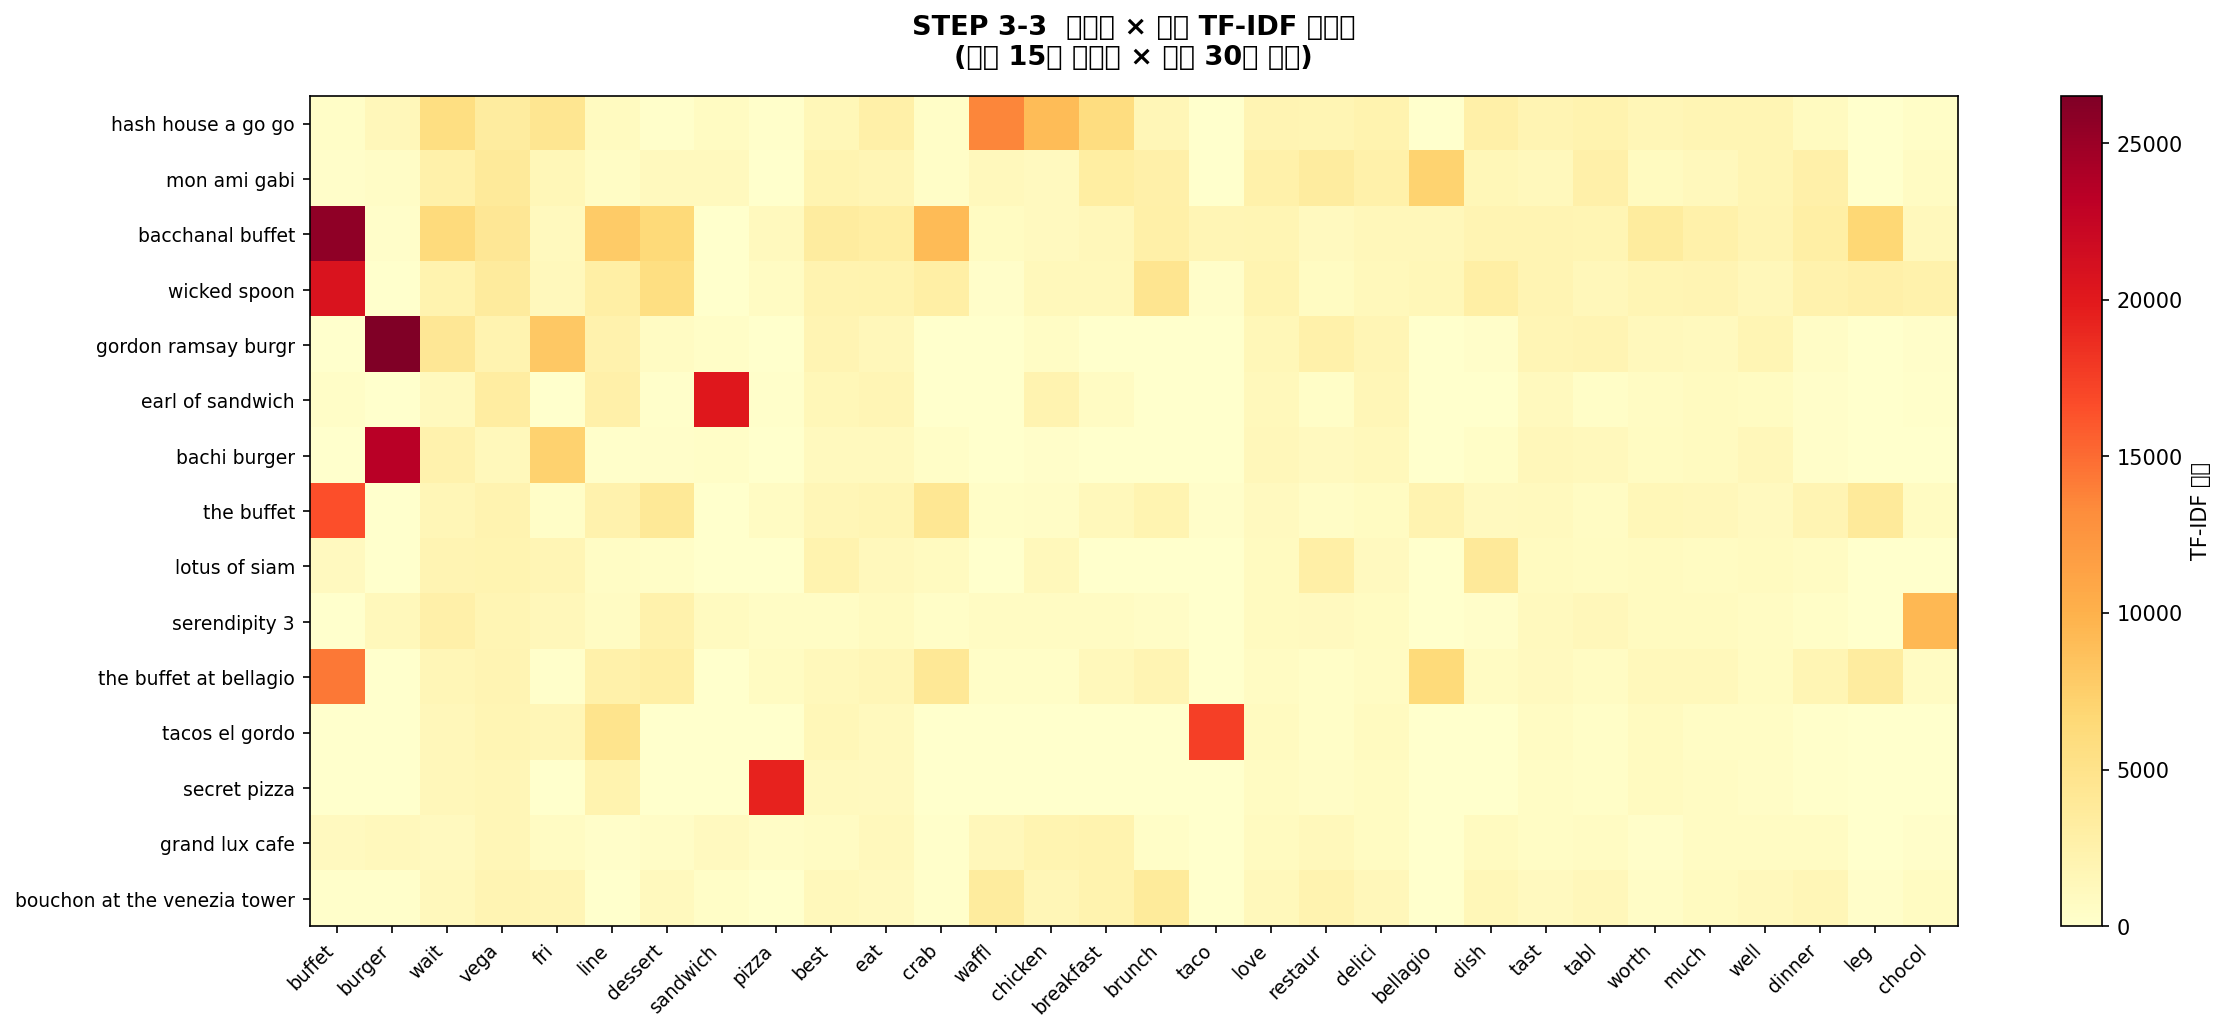

**결과 해석 (주요 브랜드별 특징 단어)**

| 브랜드 | 특징 단어 | 해석 |
|--------|-----------|------|
| Bacchanal Buffet | buffet | 뷔페 전문점 특성 반영 |
| Gordon Ramsay Burger | burger | 버거 전문점 특성 반영 |
| Tacos El Gordo | taco | 타코 전문점 특성 반영 |
| Secret Pizza | pizza | 피자 전문점 특성 반영 |
| Earl of Sandwich | sandwich | 샌드위치 전문점 특성 반영 |

In [7]:
def step3_4_3_heatmap(df_tfidf, top_n_brands=15, top_n_words=30):
    print("\n" + "="*60)
    print("STEP 3-4-3  브랜드 × 단어 TF-IDF 히트맵")
    print("="*60)

    meta_cols  = [col for col in df_tfidf.columns if col in META_COLS_POOL]
    tfidf_cols = [col for col in df_tfidf.columns if col not in meta_cols]

    df_plot = df_tfidf.copy()
    if 'review_count' in df_plot.columns:
        df_plot = df_plot.nlargest(top_n_brands, 'review_count')
    else:
        df_plot = df_plot.head(top_n_brands)

    brand_labels = df_plot['name'] if 'name' in df_plot.columns else df_plot.index.astype(str)
    top_words    = df_plot[tfidf_cols].mean(axis=0).nlargest(top_n_words).index.tolist()
    heatmap_data = df_plot[top_words].values

    fig, ax = plt.subplots(figsize=(16, 7))
    im = ax.imshow(heatmap_data, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(top_words)))
    ax.set_xticklabels(top_words, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(brand_labels)))
    ax.set_yticklabels(brand_labels.values, fontsize=9)
    ax.set_title(f'STEP 3-3  브랜드 × 단어 TF-IDF 히트맵\n'
                 f'(상위 {top_n_brands}개 브랜드 × 상위 {top_n_words}개 단어)',
                 fontsize=13, fontweight='bold', pad=15)
    plt.colorbar(im, ax=ax, label='TF-IDF 점수')
    plt.tight_layout()
    plt.savefig(f"{PATH_to_save}/viz_3_4_3_heatmap.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("  -> 저장 완료: viz_3_4_3_heatmap.png")

---
## 전체 파이프라인 실행 (실행 결과는 위에 결과 분석에 포함해두었음)

### 실행 순서
1. STEP 3-1 클리닝
2. STEP 3-2 DTM 생성 × 2조건 (`min_review_prop = 0.3`, `0.1`)
3. STEP 3-3 TF-IDF 변환 × 각 2버전 (norm 없음, L2)
4. STEP 3-4 시각화 3종


STEP 3-1  텍스트 클리닝
  [3-1-0] biz_target.csv / review_target.csv 로드 중...
          -> 업체 수: 5,899개 / 리뷰 수: 929,606개
  [3-1-1] 브랜드별 리뷰 aggregation 중...
          -> 브랜드 수: 4,228개
  [3-1-2] 소문자화 / 숫자·구두점 제거 / 어간추출 중... (시간 소요)


텍스트 전처리: 100%|██████████| 423/423 [13:16<00:00,  1.88s/it] 


  -> 저장 완료: reviews_restaurants_nv_perBrand.csv  (4,228개 브랜드)

STEP 3-2  DTM 생성  (min_review_prop=0.3)
  [3-2-1] CountVectorizer로 초기 DTM 생성 중...
          -> 초기 단어 수: 353,385개
  [3-2-2] df_rate 기준 희소·공통 단어 제거 중...
          -> 희소단어 제거: 350,065개 / 공통단어 제거: 24개
          -> 남은 단어 수: 3,296개
  [3-2-3] 문서별 min_review_prop 기준 단어 필터링 중...
          -> review_prop 필터 후 단어 수: 2,801개
  [3-2-4] 최소 문서수 기준 추가 필터링 중...
          -> 최종 단어 수: 945개
  [3-2-5] 수동 불용어 제거 중...
  -> 저장 완료: reviews_restaurants_nv_perBrand_0.1_0.9_0.3_10_dtm.csv

STEP 3-3  TF-IDF 변환  (L2 norm: False)
  -> 저장 완료: reviews_restaurants_nv_perBrand_0.1_0.9_0.3_10_dtm_tfidf.csv

STEP 3-3  TF-IDF 변환  (L2 norm: True)
  -> 저장 완료: reviews_restaurants_nv_perBrand_0.1_0.9_0.3_10_dtm_tfidf_l2.csv

STEP 3-2  DTM 생성  (min_review_prop=0.1)
  [3-2-1] CountVectorizer로 초기 DTM 생성 중...
          -> 초기 단어 수: 353,385개
  [3-2-2] df_rate 기준 희소·공통 단어 제거 중...
          -> 희소단어 제거: 350,065개 / 공통단어 제거: 24개
          -> 남은 단어 수: 3,296개
  [3-2-3] 문서별 min_r

C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\398572209.py:34: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\398572209.py:34: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\398572209.py:34: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\398572209.py:34: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\398572209.py:34: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\398572209.py:34: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) 

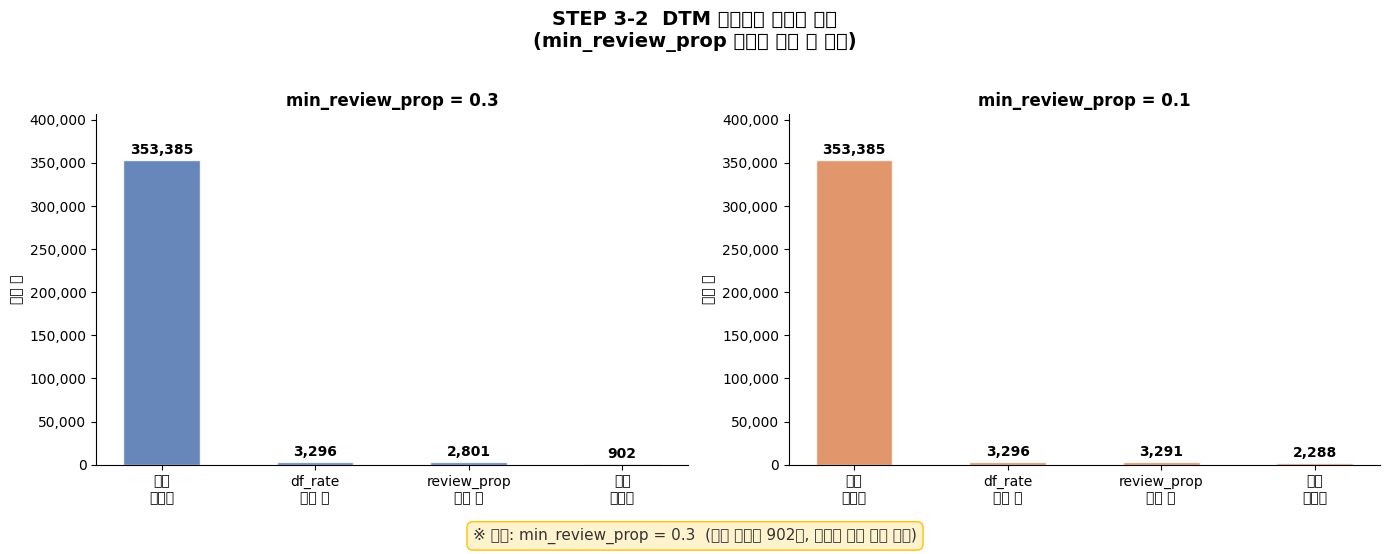

  -> 저장 완료: viz_3_4_1_param_comparison.png

STEP 3-4-2  TF-IDF 워드클라우드


C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\3269889339.py:23: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\3269889339.py:23: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\3269889339.py:23: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\3269889339.py:23: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\3269889339.py:23: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\3269889339.py:23: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing fro

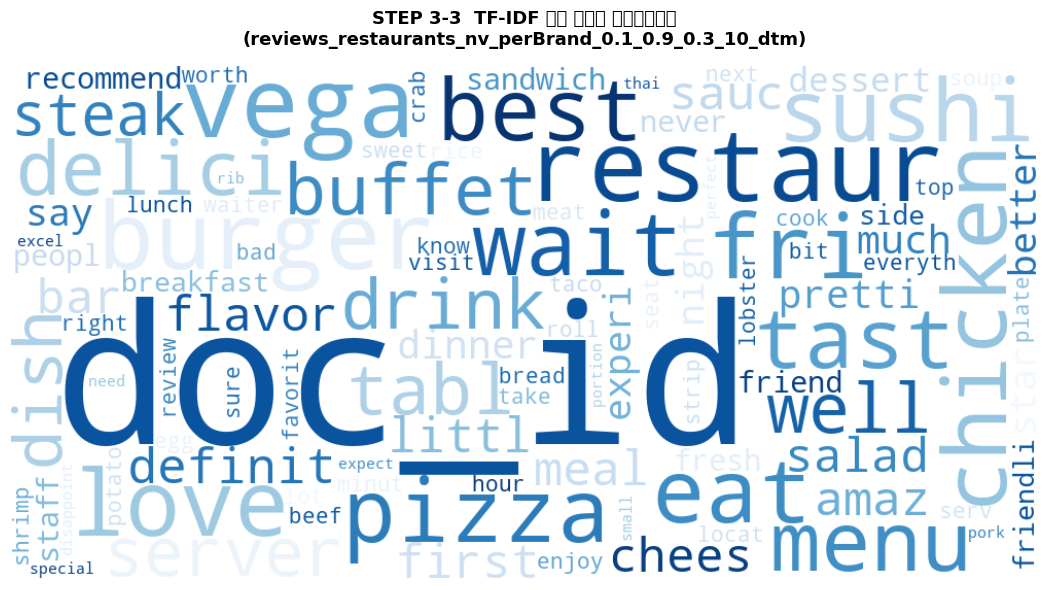

  -> 저장 완료: viz_3_4_2_wordcloud.png

STEP 3-4-3  브랜드 × 단어 TF-IDF 히트맵


C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\3286614726.py:29: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\3286614726.py:29: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\3286614726.py:29: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\3286614726.py:29: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\3286614726.py:29: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seonu\AppData\Local\Temp\ipykernel_28380\3286614726.py:29: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from

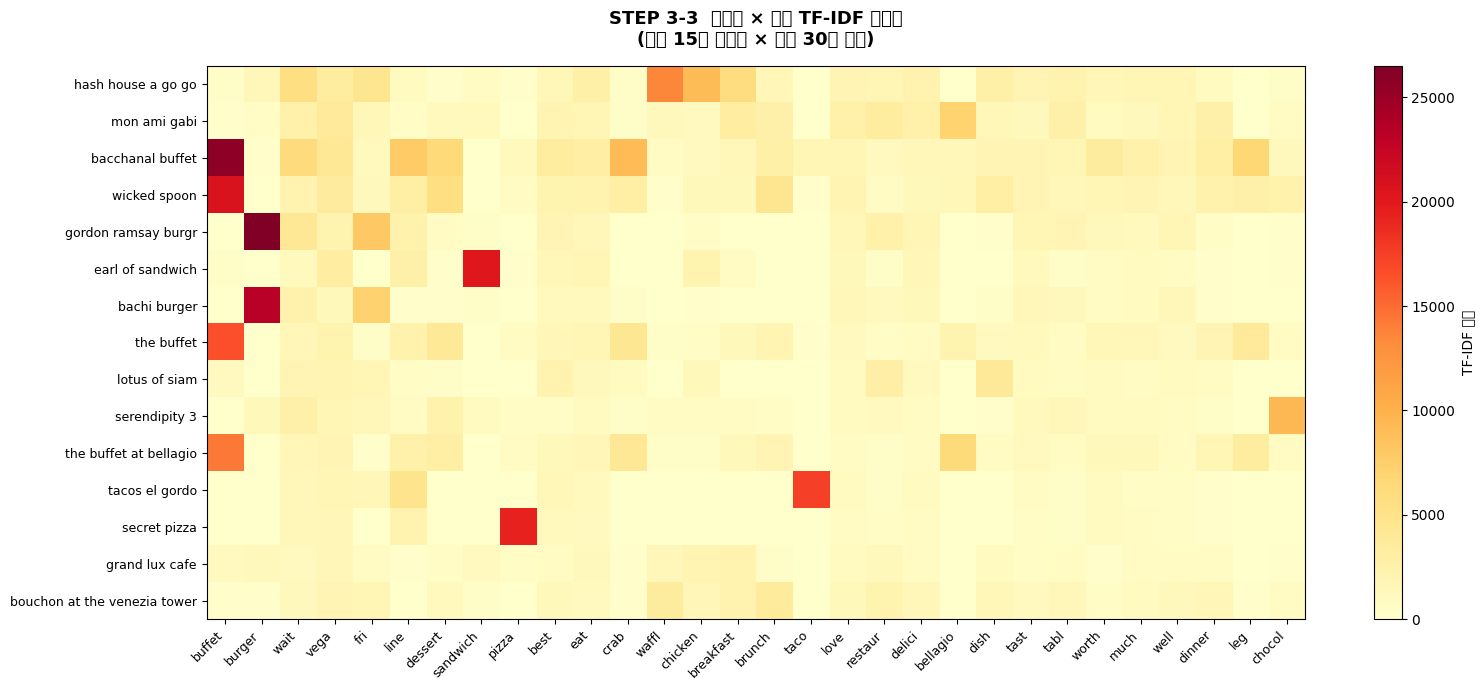

  -> 저장 완료: viz_3_4_3_heatmap.png

모든 파이프라인 완료!


In [9]:
# STEP 3-1: 클리닝
brand_reviews, base_name = step3_1_cleaning()

# STEP 3-2 & 3-3: 조건별 DTM + TF-IDF
word_count_logs = {}
results         = {}

for prop in REVIEW_PROP_CONDITIONS:
    brand_reviews_dtm, dtm_file_name, wc_log = step3_2_dtm(
        brand_reviews          = brand_reviews,
        input_file_name        = base_name,
        min_df_rate            = MIN_DF_RATE,
        max_df_rate            = MAX_DF_RATE,
        min_review_prop_in_doc = prop,
        min_doc_count_finally  = MIN_DOC_COUNT,
        manual_stopwords       = MANUAL_STOPWORDS,
    )
    word_count_logs[prop] = wc_log

    df_tfidf    = step3_3_tfidf(brand_reviews_dtm, dtm_file_name, apply_l2=False)
    df_tfidf_l2 = step3_3_tfidf(brand_reviews_dtm, dtm_file_name, apply_l2=True)
    results[prop] = {
        'dtm': brand_reviews_dtm,
        'tfidf': df_tfidf,
        'tfidf_l2': df_tfidf_l2,
        'dtm_file_name': dtm_file_name
    }

# STEP 3-4: 시각화
step3_4_1_param_comparison(word_count_logs)

chosen_prop     = REVIEW_PROP_CONDITIONS[0]
chosen_tfidf    = results[chosen_prop]['tfidf']
chosen_dtm_name = results[chosen_prop]['dtm_file_name']

step3_4_2_wordcloud(chosen_tfidf, chosen_dtm_name)
step3_4_3_heatmap(chosen_tfidf, top_n_brands=15, top_n_words=30)

print("\n" + "="*60)
print("모든 파이프라인 완료!")
print("="*60)

---
## 최종 결과 검증

저장된 파일을 불러와 정상적으로 생성되었는지 확인합니다.

**확인 항목**
- 클리닝 결과: 브랜드 수 4,228개, 결측치 없음
- TF-IDF 결과: (4,228 × 메타컬럼+단어수) 형태

In [10]:
import pandas as pd

# 1. 클리닝 결과 확인
df = pd.read_csv(r'C:\Users\seonu\Documents\yelp-franchise-analysis\results\reviews_restaurants_nv_perBrand.csv')
print(df.shape)  # (4228, 컬럼수) 나와야 함
print(df['pooled_text_clean'].isna().sum())  # 0이어야 함
print(df[['name','review_count','pooled_text_clean']].head(3))

# 2. TF-IDF 결과 확인
tfidf = pd.read_csv(r'C:\Users\seonu\Documents\yelp-franchise-analysis\results\reviews_restaurants_nv_perBrand_0.1_0.9_0.3_10_dtm_tfidf.csv')
print(tfidf.shape)  # (4228, 메타컬럼+단어수)
print(tfidf.iloc[:, :8].head(3))  # 앞 컬럼 확인

(4228, 9)
0
                 name  review_count  \
0  hash house a go go          9000   
1        mon ami gabi          7362   
2    bacchanal buffet          7006   

                                   pooled_text_clean  
0  ate restaur hotel casino yesterday share exper...  
1  tradit french fare heart la vega strip never f...  
2  date time tuesday pm buffet two peopl price ch...  
(4228, 910)
                 name  review_count  avg_stars  useful_count  funny_count  \
0  hash house a go go          9000   3.817889          6576         3717   
1        mon ami gabi          7362   4.120484          5433         2831   
2    bacchanal buffet          7006   3.770340         11006         5330   

   cool_count                                         categories   doc_id  
0        4229      Restaurants;Breakfast & Brunch;American (New)  0.00000  
1        3747  French;Steakhouses;Restaurants;Breakfast & Brunch  1.00024  
2        6039  Sandwiches;Buffets;Restaurants;Breakfast & Bru.